In [13]:
from spin_lattices import ChainLattice, SquareLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from mvmc_configs import MVMCConfig
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from lattice_boolean_analysis import LBFFromEigenstateSeries
from fast_boolean_analysis import fourier_expand
from misc_utils import get_abslargest_terms
from typing import Any
import seaborn as sns

In [14]:
%matplotlib inline

In [15]:
def add_prefix_to_keys(d: dict[str, Any], prefix: str) -> dict[str, Any]:
    return {prefix + k: v for k, v in d.items()}


In [16]:
def get_sign_complexity(system, wavefunction):
    signal = LBFFromEigenstateSeries(system.lattice, np.sign(wavefunction))
    series = fourier_expand(signal)
    iipr = 1 / series.ipr(ignore_free_term=True)
    success, terms, _ = series.how_many_terms_to_achieve_score(0.8, "accuracy")
    total_hamming_weight = series.total_hamming_weight(terms)
    subsets, coeffs = get_abslargest_terms(series.coeffs, terms)
    return {
        "iipr": iipr,
        "terms": terms,
        "success": success,
        "total_hamming_weight": total_hamming_weight,
        "subsets": subsets,
        "coeffs": coeffs,
    }


In [42]:
lattice = KagomeLattice(2, 4)
J2s = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]

def analyze_mvmc_vs_ed(lattice, J2s, iterations: int = 1, mvmc_opts: dict[str, Any] | None = None):
    rows = []

    if mvmc_opts is None:
        mvmc_opts = {}

    for J2 in J2s:
        system = HeisenbergJ1J2(
            lattice, J1=1, J2=J2, ground_state_cache_dir=Path("groundstates")
        )
        ed_energy, _ = system.get_eigenstates(1)
        ed_series = system.get_df_ground_state(canonical_basis=True)[
            "eigenstate_coeff"
        ].sort_index()
        ed_wavefunction = np.asarray(ed_series.values)
        ed_sign_complexity = get_sign_complexity(system, ed_series)
        rows.append({
            "J2": J2,
            "energy": ed_energy[0],
            "type": "ed",
        } | ed_sign_complexity)
        for iteration in range(iterations):
            mvmc = MVMCConfig(system=system, total_spin=0, **mvmc_opts)
            mvmc_series, mvmc_energy = mvmc.get_ground_state(report_energy=True)
            mvmc_wavefunction = np.asarray(mvmc_series.values)
            assert (mvmc_series.index == ed_series.index).all()
            overlap = (
                (ed_wavefunction * mvmc_wavefunction).sum()
                / np.linalg.norm(mvmc_wavefunction)
                / np.linalg.norm(ed_wavefunction)
            )
            mvmc_sign_complexity = get_sign_complexity(system, mvmc_series)
            rows.append({
                "J2": J2,
                "overlap": np.real_if_close(overlap),
                "iteration": iteration,
                "energy": mvmc_energy[-1] * 4,
                "energy_full": mvmc_energy * 4,
                "type": "mvmc",
                "iteration": iteration,
            } | mvmc_sign_complexity)
        df = pd.DataFrame(rows)
    return df


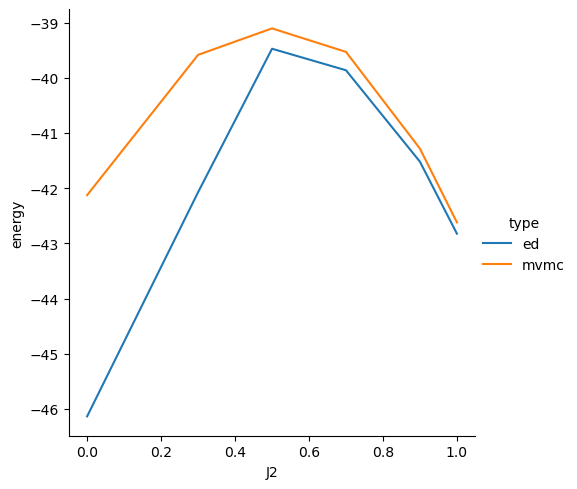

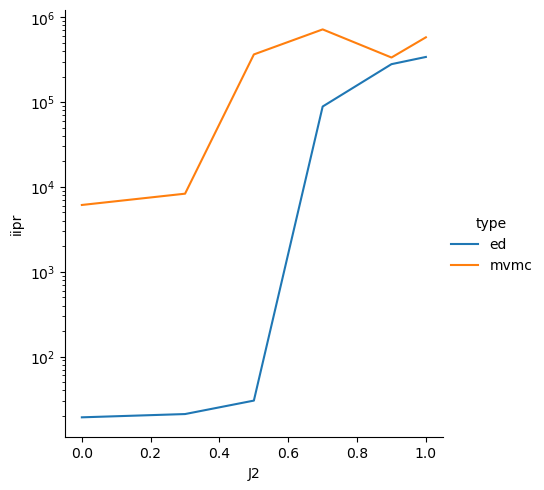

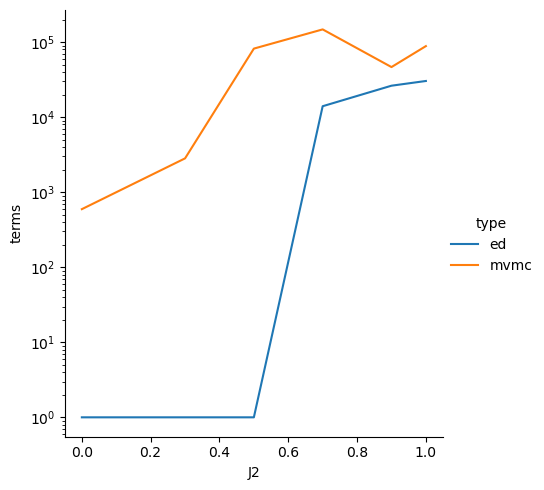

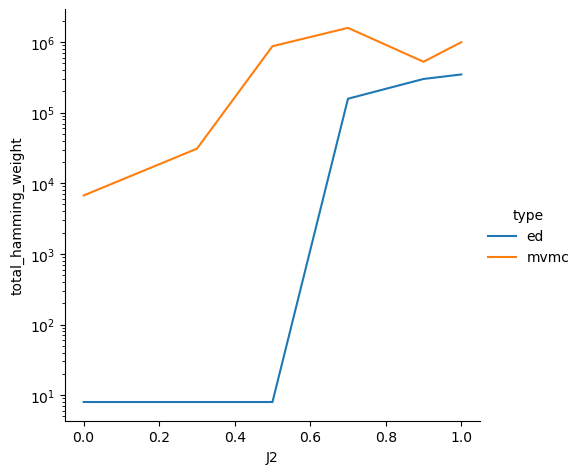

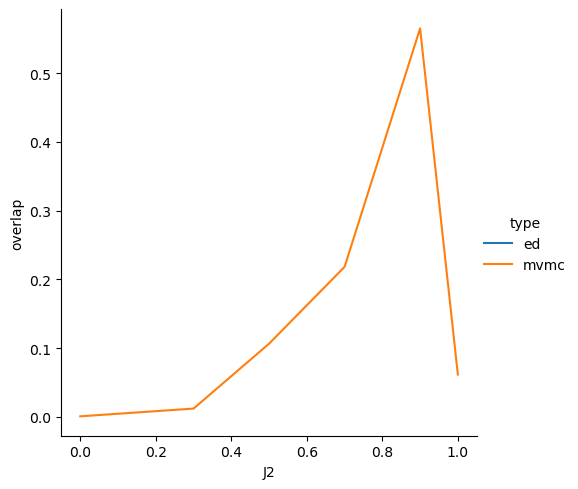

In [61]:
for column in df.columns.drop(["J2", "type", "success", "subsets", "coeffs", "energy_full"]):
    g = sns.relplot(df,
        x="J2",
        y=column,
        hue="type",
        kind="line",)
    if column not in {"energy", "overlap"}:
        g.set(yscale="log")

In [ ]:
lattice = SquareLattice(6, 4)
J2s = [0., 0.5, 0.8,1.0]
df_square = analyze_mvmc_vs_ed(lattice, J2s)

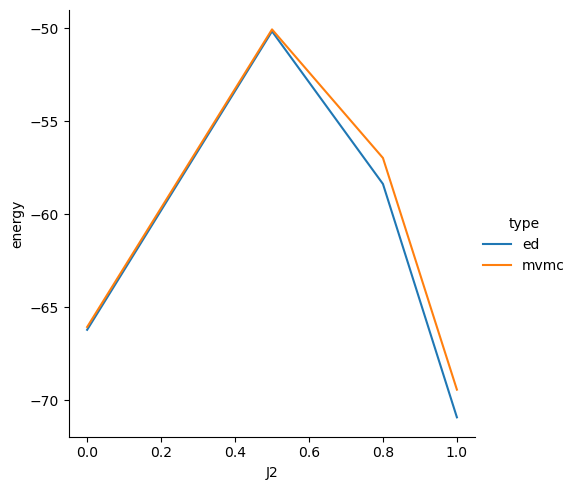

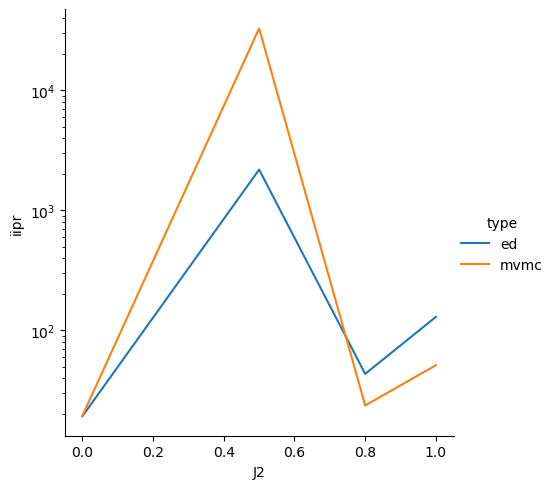

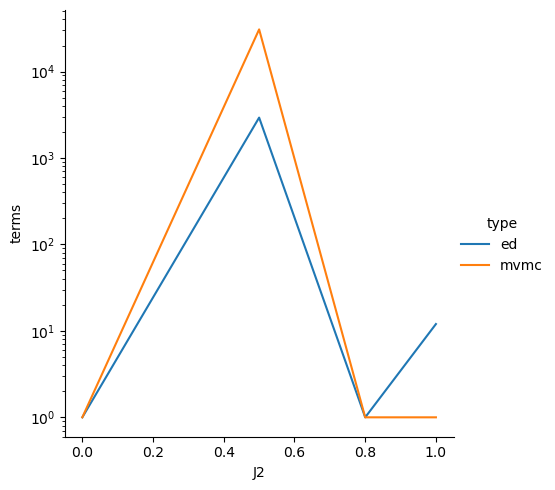

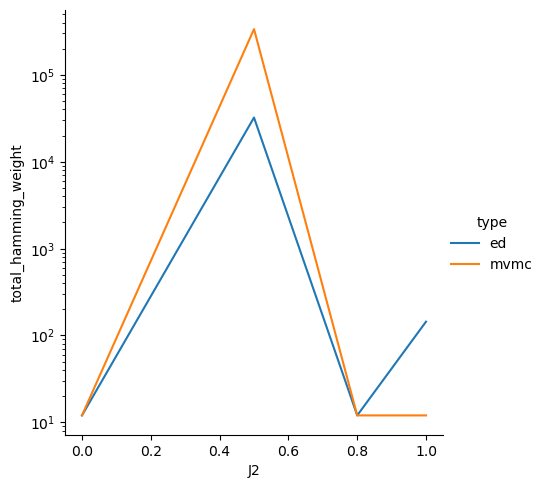

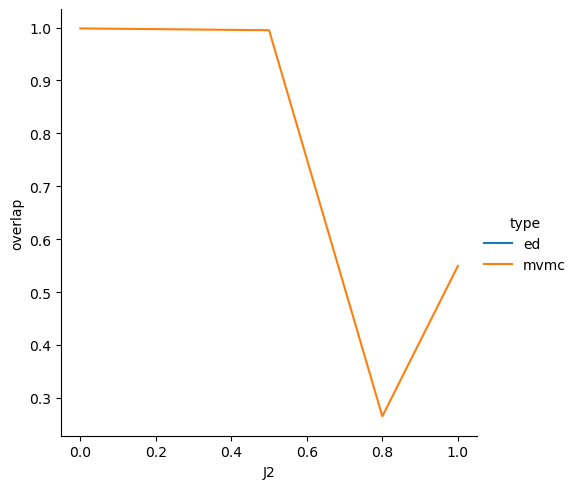

In [64]:
for column in df.columns.drop(["J2", "type", "success", "subsets", "coeffs", "energy_full"]):
    g = sns.relplot(df_square,
        x="J2",
        y=column,
        hue="type",
        kind="line",)
    if column not in {"energy", "overlap"}:
        g.set(yscale="log")

In [36]:
lattice = SquareLattice(6, 4)
J2s = [0., 0.3, 0.5, 0.7, 0.9, 1.]
df_square = analyze_mvmc_vs_ed(lattice, J2s, iterations=5, mvmc_opts=dict(NSROptItrStep=200, DSROptStepDt=0.02))

2023-03-24 15:23:58.246 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-03-24 15:23:58.249 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-03-24 15:23:58.277 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 96 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-03-24 15:23:58.366 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 15578
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-03-24 15:23:58.461 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice6x4-1.0-0.8-True-1-1.pickle
2023-03-24 15:23:58.466 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -58.3690076957
2023-03-24 15:23:58.467 | DEBUG    | heisenberg

Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.
Start: Initialize parameters

remark: FlagShift ( GJ ) is turned on.


Progress of Optimization: 5 %.
Progress of Optimization: 10 %.
Progress of Optimization: 15 %.
Progress of Optimization: 20 %.
Progress of Optimization: 25 %.
Progress of Optimization: 30 %.
Progress of Optimization: 35 %.
Progress of Optimization: 40 %.
Progress of Optimization: 45 %.
Progress of Optimization: 50 %.
Progress of Optimization: 55 %.
Progress of Optimization: 60 %.
Progress of Optimization: 65 %.
Progress of Optimization: 70 %.
Progress of Optimization: 75 %.
Progress of Optimization: 80 %.
Progress of Optimization: 85 %.
Progress of Optimization: 90 %.
Progress of Optimization: 95 %.
Start: Output opt params.
End: Output opt params.
End  : Optimize VMC parameters.
Start: Free Memory.
End: Free Memory.
Finish calculation.


Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.
Start: Initialize parameters

...

Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679668077
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


remark: FlagShift ( GJ ) is turned on.


Progress of Optimization: 5 %.
Progress of Optimization: 10 %.
Progress of Optimization: 15 %.
Progress of Optimization: 20 %.
Progress of Optimization: 25 %.
Progress of Optimization: 30 %.
Progress of Optimization: 35 %.
Progress of Optimization: 40 %.
Progress of Optimization: 45 %.
Progress of Optimization: 50 %.
Progress of Optimization: 55 %.
Progress of Optimization: 60 %.
Progress of Optimization: 65 %.
Progress of Optimization: 70 %.
Progress of Optimization: 75 %.
Progress of Optimization: 80 %.
Progress of Optimization: 85 %.
Progress of Optimization: 90 %.
Progress of Optimization: 95 %.
Start: Output opt params.
End: Output opt params.
End  : Optimize VMC parameters.
Start: Free Memory.
End: Free Memory.
Finish calculation.


Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679668239
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


InitWaveFunctionExtraction: opening 'wavefunction.dat' ...
InitWaveFunctionExtraction: all wave function evaluations will be written to it
Walking complete; stopping the program now ...
Abort(0) on node 0 (rank 0 in comm 480): application called MPI_Abort(comm=0x84000001, 0) - process 0
vmc.out: no process found
2023-03-24 15:31:33.981 | DEBUG    | fast_boolean_analysis:fourier_expand:245 - Finding signal
2023-03-24 15:31:34.450 | DEBUG    | fast_boolean_analysis:fourier_expand:247 - Doing 
2023-03-24 15:31:37.194 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:156 - At min_terms=1, score=0.8221378500352791 >= target_score=0.8, so we can achieve the target score with 1 terms


In [39]:
lattice = KagomeLattice(2, 4)
J2s = [0.]
df_kagome = analyze_mvmc_vs_ed(lattice, J2s, iterations=5, mvmc_opts=dict(NSROptItrStep=200, DSROptStepDt=0.02))

2023-03-24 15:37:34.569 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-03-24 15:37:34.570 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-03-24 15:37:34.575 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-03-24 15:37:34.756 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 85662
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-03-24 15:37:34.829 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-03-24 15:37:34.938 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -46.1341392314
2023-03-24 15:37:34.940 | DEBUG    | heisenberg

Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679668667
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


remark: FlagShift ( GJ ) is turned on.


Progress of Optimization: 5 %.
Progress of Optimization: 10 %.
Progress of Optimization: 15 %.
Progress of Optimization: 20 %.
Progress of Optimization: 25 %.
Progress of Optimization: 30 %.
Progress of Optimization: 35 %.
Progress of Optimization: 40 %.
Progress of Optimization: 45 %.
Progress of Optimization: 50 %.
Progress of Optimization: 55 %.
Progress of Optimization: 60 %.
Progress of Optimization: 65 %.
Progress of Optimization: 70 %.
Progress of Optimization: 75 %.
Progress of Optimization: 80 %.
Progress of Optimization: 85 %.
Progress of Optimization: 90 %.
Progress of Optimization: 95 %.
Start: Output opt params.
End: Output opt params.
End  : Optimize VMC parameters.
Start: Free Memory.
End: Free Memory.
Finish calculation.


Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679668762
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


...

Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679669473
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


remark: FlagShift ( GJ ) is turned on.


Progress of Optimization: 5 %.
Progress of Optimization: 10 %.
Progress of Optimization: 15 %.
Progress of Optimization: 20 %.
Progress of Optimization: 25 %.
Progress of Optimization: 30 %.
Progress of Optimization: 35 %.
Progress of Optimization: 40 %.
Progress of Optimization: 45 %.
Progress of Optimization: 50 %.
Progress of Optimization: 55 %.
Progress of Optimization: 60 %.
Progress of Optimization: 65 %.
Progress of Optimization: 70 %.
Progress of Optimization: 75 %.
Progress of Optimization: 80 %.
Progress of Optimization: 85 %.
Progress of Optimization: 90 %.
Progress of Optimization: 95 %.
Start: Output opt params.
End: Output opt params.
End  : Optimize VMC parameters.
Start: Free Memory.
End: Free Memory.
Finish calculation.


Start: Read *def files.
  Read File namelist.def .
Start: Read ModPara File .
  remark: Seed = 1679669567
End: Read ModPara File .
  Read File 'modpara.def' for ModPara.
  Read File 'locspn.def' for LocSpin.
  Read File 'trans.def' for Trans.
  Read File 'coulombinter.def' for CoulombInter.
  Read File 'hund.def' for Hund.
  Read File 'exchange.def' for Exchange.
  Read File 'gutzwilleridx.def' for Gutzwiller.
  Read File 'jastrowidx.def' for Jastrow.
  Read File 'orbitalidx.def' for Orbital.
  Read File 'qptransidx.def' for TransSym.
  Read File 'greenone.def' for OneBodyG.
  Read File 'greentwo.def' for TwoBodyG.
End  : Read *def files.
Start: Read parameters from *def files.
     locspn.def
     trans.def
     coulombinter.def
     hund.def
     exchange.def
     gutzwilleridx.def
     jastrowidx.def
     orbitalidx.def
     qptransidx.def
     greenone.def
     greentwo.def
finish reading parameters.
End  : Read parameters from *def files.
Start: Set memories.
End  : Set memories.


InitWaveFunctionExtraction: opening 'wavefunction.dat' ...
InitWaveFunctionExtraction: all wave function evaluations will be written to it
Walking complete; stopping the program now ...
Abort(0) on node 0 (rank 0 in comm 480): application called MPI_Abort(comm=0x84000001, 0) - process 0
vmc.out: no process found
2023-03-24 15:53:43.674 | DEBUG    | fast_boolean_analysis:fourier_expand:245 - Finding signal
2023-03-24 15:53:44.166 | DEBUG    | fast_boolean_analysis:fourier_expand:247 - Doing 
2023-03-24 15:53:46.958 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:162 - min_terms=1, max_terms=16777216
2023-03-24 15:53:48.236 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:165 - mid=8388608, score=1.0
2023-03-24 15:53:48.237 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:168 - score >= target_score, so we can decrease max_terms
2023-03-24 15:53:48.238 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:162 - min_terms

In [53]:
df_kagome.query("J2 == 0.")['energy'] / 4

3   -11.533535
4   -10.171303
5   -10.467473
6   -10.486043
7   -10.456626
8   -10.530878
Name: energy, dtype: float64

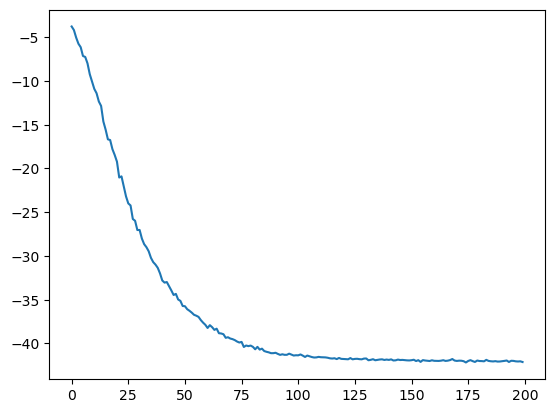

In [46]:
plt.plot(df_kagome.query("J2 == 0.").loc[8]['energy_full'])

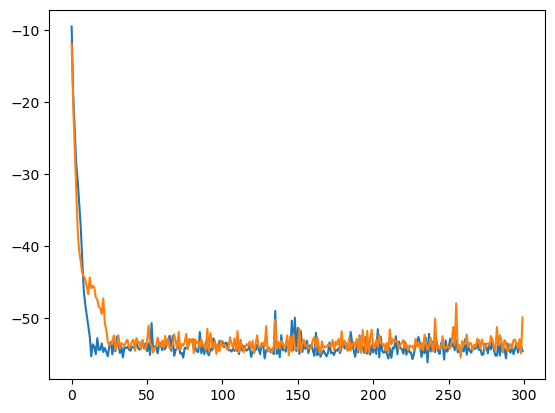

In [38]:
plt.plot(df_square.iloc[1]['energy_full'])
plt.plot(df_square.iloc[2]['energy_full'])

In [ ]:
lattice = KagomeLattice(2, 3)
J2s = [0.]
df_kagome = analyze_mvmc_vs_ed(lattice, J2s, iterations=5, mvmc_opts=dict(NSROptItrStep=200, DSROptStepDt=0.02))

In [60]:
df_kagome['overlap'] = df_kagome['overlap'].astype(np.float64)

In [61]:
df_kagome.to_feather("df_kagome.feather")

In [81]:
from mvmc_multi_2023_03_24 import outdir

In [82]:
dfs = []
for feather in outdir.glob("*.feather"):
    df = pd.read_feather(feather)
    dfs.append(df)
df = pd.concat(dfs)

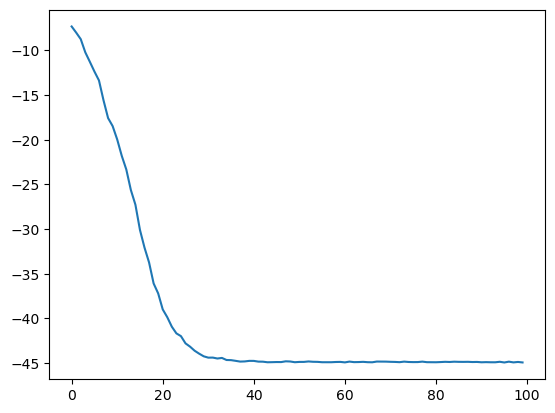

In [85]:
plt.plot(df.iloc[1]['energy_full'])

In [80]:
directory = Path(".")
pd.read_csv(
            directory /  "zvo_out_001.dat", sep=r"\s+", index_col=None, header=None,
            names=["energy_real", "energy_imag", "energy_square", "energy_variance", "sz", "sz_squared"]
        )

,energy_real,energy_imag,energy_square,energy_variance,sz,sz_squared
0,-1.289569,0.0,7.603710,3.572318,0.0,0.0
1,-1.371409,0.0,8.480054,3.508841,0.0,0.0
2,-1.498994,0.0,8.713302,2.877780,0.0,0.0
3,-1.773396,0.0,8.368889,1.661072,0.0,0.0
4,-2.139347,0.0,12.417629,1.713165,0.0,0.0
...,...,...,...,...,...,...
595,-10.530177,0.0,111.195142,0.002800,0.0,0.0
596,-10.518821,0.0,110.822816,0.001602,0.0,0.0
597,-10.579539,0.0,112.143684,0.001939,0.0,0.0
598,-10.508991,0.0,110.609791,0.001548,0.0,0.0
